In [1]:
import sys
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image
from scipy import ndimage

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.config import (
    DATA_DIR,
    IMAGE_DIR,
    METADATA_PATH,
    GROUND_TRUTH_PATH,
)

np.set_printoptions(precision=2, suppress=True)

print("Project root:", PROJECT_ROOT)
print("Image directory:", IMAGE_DIR)

Project root: c:\Users\Kinjal Chatterjee\Desktop\MILK10K-Project
Image directory: C:\Users\Kinjal Chatterjee\Downloads\MILK10k\images


In [2]:
metadata = pd.read_csv(METADATA_PATH)
ground_truth = pd.read_csv(GROUND_TRUTH_PATH)

label_columns = [
    "AKIEC", "BCC", "BEN_OTH", "BKL", "DF",
    "INF", "MAL_OTH", "MEL", "NV", "SCCKA", "VASC"
]

ground_truth["label"] = ground_truth[label_columns].idxmax(axis=1)

image_table = (
    metadata[["lesion_id", "isic_id", "image_type"]]
    .pivot(
        index="lesion_id",
        columns="image_type",
        values="isic_id"
    )
    .reset_index()
)

image_table = image_table.rename(columns={
    "dermoscopic": "dermoscopic_isic_id",
    "clinical: close-up": "clinical_isic_id"
})

lesion_table = (
    ground_truth[["lesion_id", "label"]]
    .merge(image_table, on="lesion_id", how="left")
)

lesion_table.head()


,lesion_id,label,clinical_isic_id,dermoscopic_isic_id
0,IL_0000652,BCC,ISIC_8149219,ISIC_4671410
1,IL_0003176,BCC,ISIC_3904045,ISIC_5371928
2,IL_0004688,BCC,ISIC_0791494,ISIC_3624913
3,IL_0005081,SCCKA,ISIC_5667730,ISIC_5186409
4,IL_0006177,BCC,ISIC_8803389,ISIC_1048297


In [3]:
selected_labels = ["BCC", "MEL", "NV", "BKL"]

samples = (
    lesion_table[lesion_table["label"].isin(selected_labels)]
    .groupby("label", group_keys=False)
    .head(1)
)

samples[["lesion_id", "label", "dermoscopic_isic_id"]]

,lesion_id,label,dermoscopic_isic_id
0,IL_0000652,BCC,ISIC_4671410
6,IL_0008891,NV,ISIC_5916190
12,IL_0017483,BKL,ISIC_1225678
14,IL_0019655,MEL,ISIC_2641217


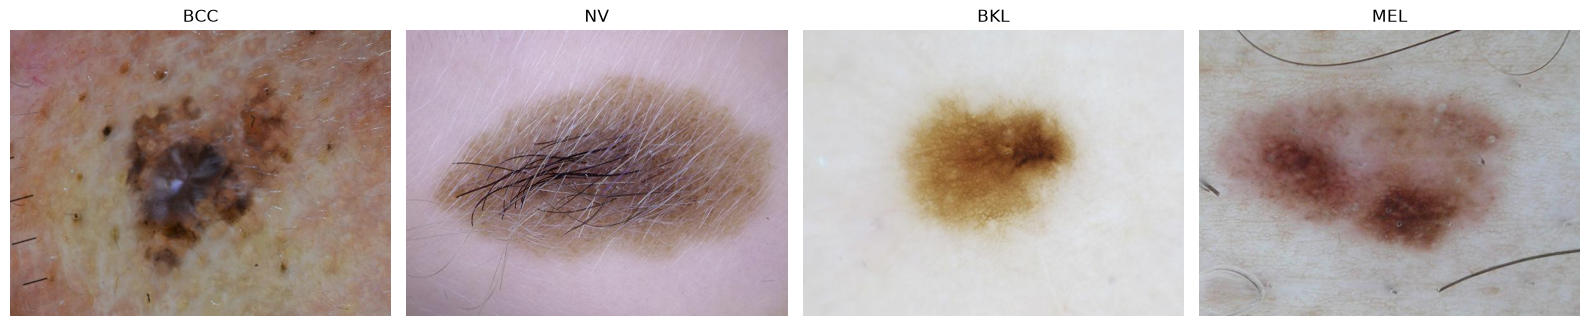

In [4]:
fig, axes = plt.subplots(1, len(samples), figsize=(16, 4))

for ax, (_, row) in zip(axes, samples.iterrows()):
    image_path = IMAGE_DIR / f"{row['dermoscopic_isic_id']}.jpg"
    
    with Image.open(image_path) as im:
        image = im.convert("RGB")
    
    ax.imshow(image)
    ax.set_title(row["label"])
    ax.axis("off")

plt.tight_layout()
plt.show()

In [5]:
import numpy as np

KERNELS = {
    "identity": np.array([[0, 0, 0],
                          [0, 1, 0],
                          [0, 0, 0]]),

    "box_blur": np.ones((3, 3)) / 9,

    "gaussian": np.array([[1, 2, 1],
                          [2, 4, 2],
                          [1, 2, 1]]) / 16,

    "sharpen": np.array([[ 0, -1,  0],
                         [-1,  5, -1],
                         [ 0, -1,  0]]),

    "outline": np.array([[-1, -1, -1],
                         [-1,  8, -1],
                         [-1, -1, -1]]),

    "emboss": np.array([[-2, -1, 0],
                        [-1,  1, 1],
                        [ 0,  1, 2]]),

    "sobel_x": np.array([[-1, 0, 1],
                         [-2, 0, 2],
                         [-1, 0, 1]]),

    "sobel_y": np.array([[-1, -2, -1],
                         [ 0,  0,  0],
                         [ 1,  2,  1]]),
}

In [6]:
def conv_step(img, kernel, row, col):
    """One window: patch -> products -> sum"""

    k = kernel.shape[0]

    patch = img[row:row+k, col:col+k]

    products = patch * kernel

    return patch, products, products.sum()

In [7]:
def output_size(n, k, padding=0, stride=1):
    return (n + 2 * padding - k) // stride + 1

In [8]:
def conv2d(img, kernel, padding=0, stride=1, pad_mode="constant"):

    k = kernel.shape[0]

    if padding > 0:
        img = np.pad(
            img,
            padding,
            mode=pad_mode
        )

    n_out = output_size(
        img.shape[0],
        k,
        padding=0,
        stride=stride
    )

    out = np.zeros((n_out, n_out))

    for r in range(n_out):
        for c in range(n_out):

            _, _, total = conv_step(
                img,
                kernel,
                r * stride,
                c * stride
            )

            out[r, c] = total

    return out

In [10]:
print(samples.columns)
print(samples.head())

Index(['lesion_id', 'label', 'clinical_isic_id', 'dermoscopic_isic_id'], dtype='str')
     lesion_id label clinical_isic_id dermoscopic_isic_id
0   IL_0000652   BCC     ISIC_8149219        ISIC_4671410
6   IL_0008891    NV     ISIC_1498519        ISIC_5916190
12  IL_0017483   BKL     ISIC_9923124        ISIC_1225678
14  IL_0019655   MEL     ISIC_1660154        ISIC_2641217


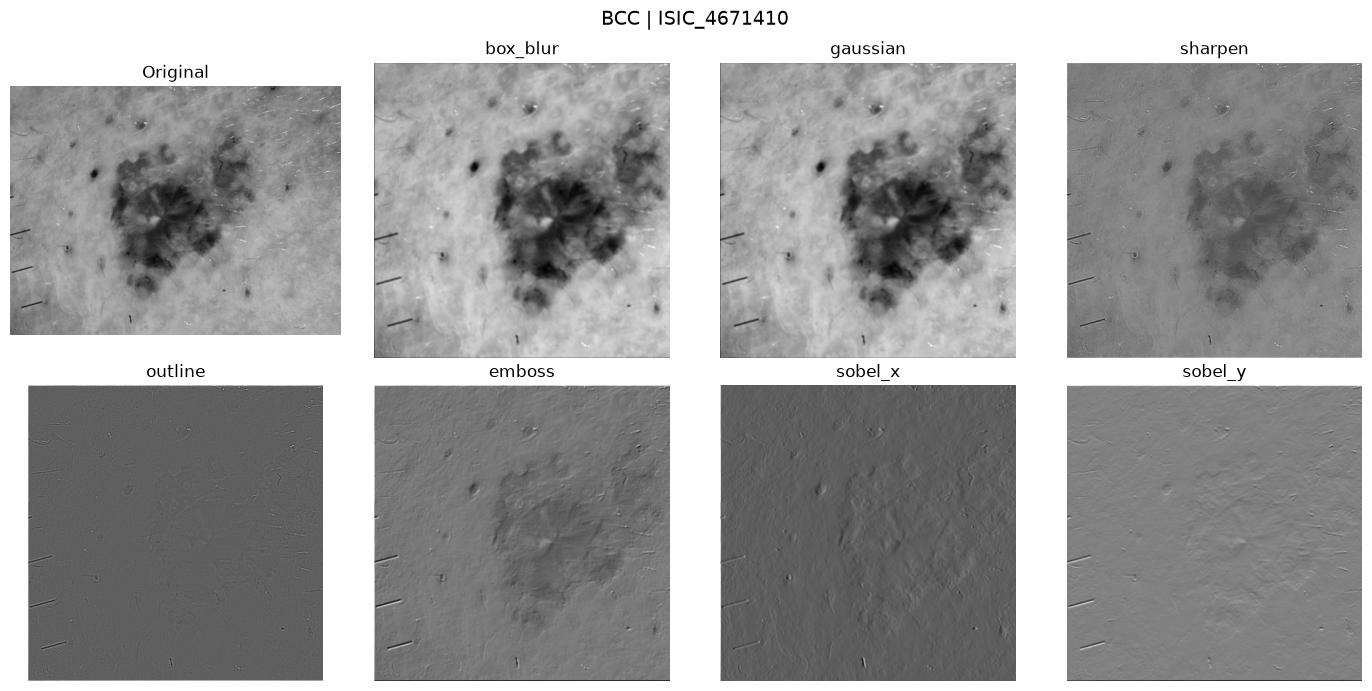

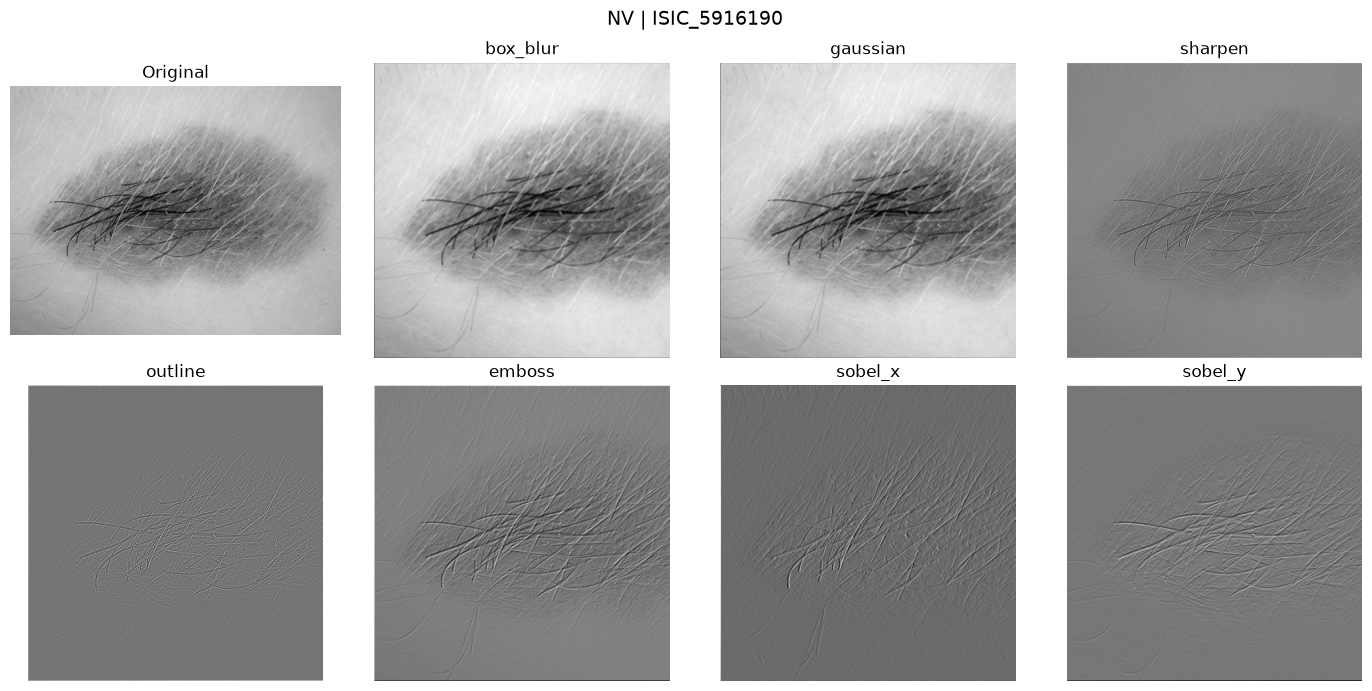

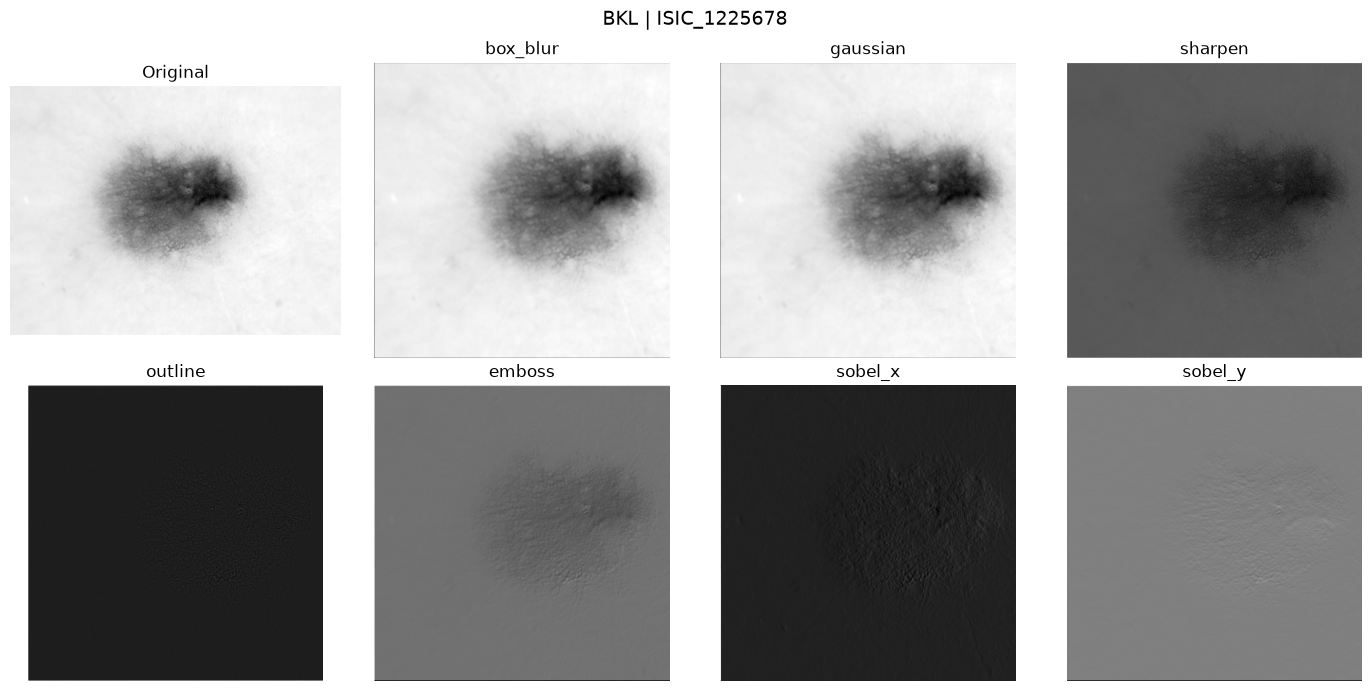

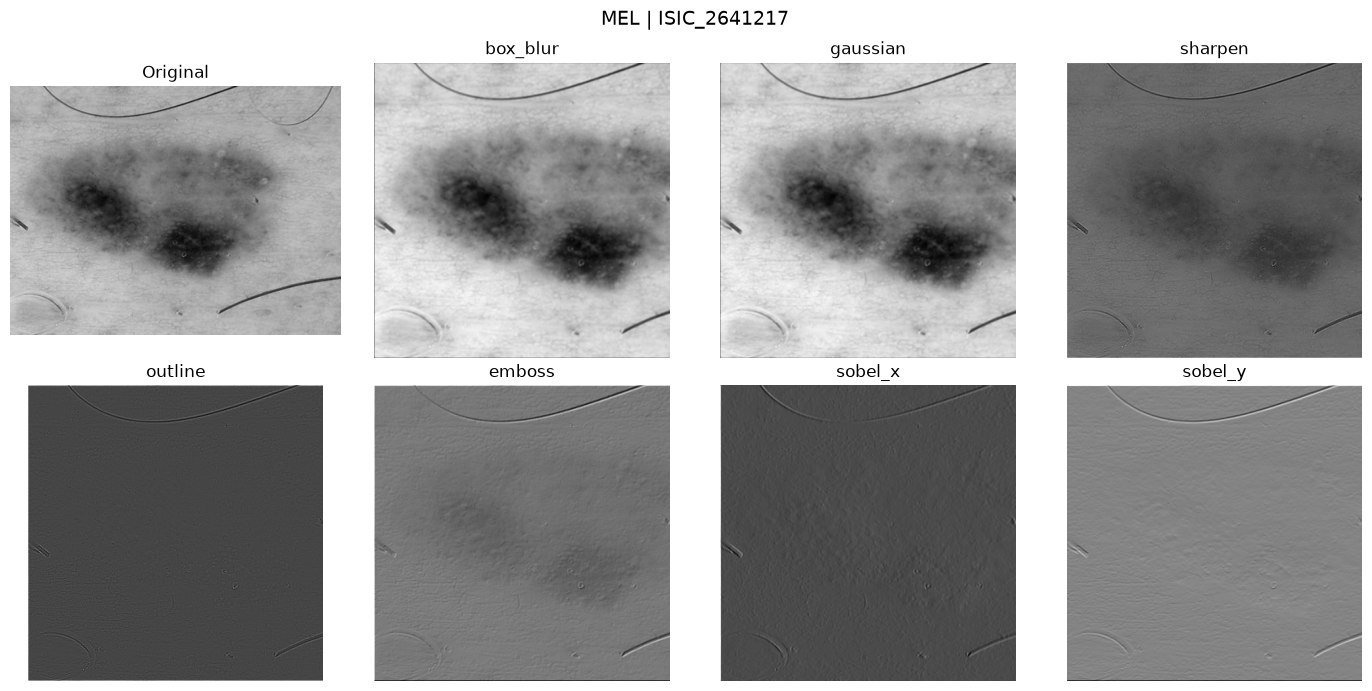

In [11]:
filter_names = [
    "box_blur",
    "gaussian",
    "sharpen",
    "outline",
    "emboss",
    "sobel_x",
    "sobel_y",
]

for _, row in samples.iterrows():

    image_path = IMAGE_DIR / f"{row['dermoscopic_isic_id']}.jpg"

    img = np.array(
        Image.open(image_path).convert("L"),
        dtype=float
    )

    fig, axes = plt.subplots(
        2, 4,
        figsize=(14, 7)
    )

    fig.suptitle(
        f"{row['label']} | {row['dermoscopic_isic_id']}",
        fontsize=14
    )

    axes = axes.ravel()

    # Original
    axes[0].imshow(img, cmap="gray")
    axes[0].set_title("Original")
    axes[0].axis("off")

    # Filters
    for ax, name in zip(axes[1:], filter_names):

        result = conv2d(
            img,
            KERNELS[name],
            padding=1,
            stride=1
        )

        ax.imshow(result, cmap="gray")
        ax.set_title(name)
        ax.axis("off")

    plt.tight_layout()
    plt.show()

In [12]:
row = samples.iloc[0]

image_path = IMAGE_DIR / f"{row['dermoscopic_isic_id']}.jpg"

img = np.array(
    Image.open(image_path).convert("L"),
    dtype=float
)

print("Class:", row["label"])
print("Image:", row["dermoscopic_isic_id"])
print("Shape:", img.shape)

Class: BCC
Image: ISIC_4671410
Shape: (450, 600)


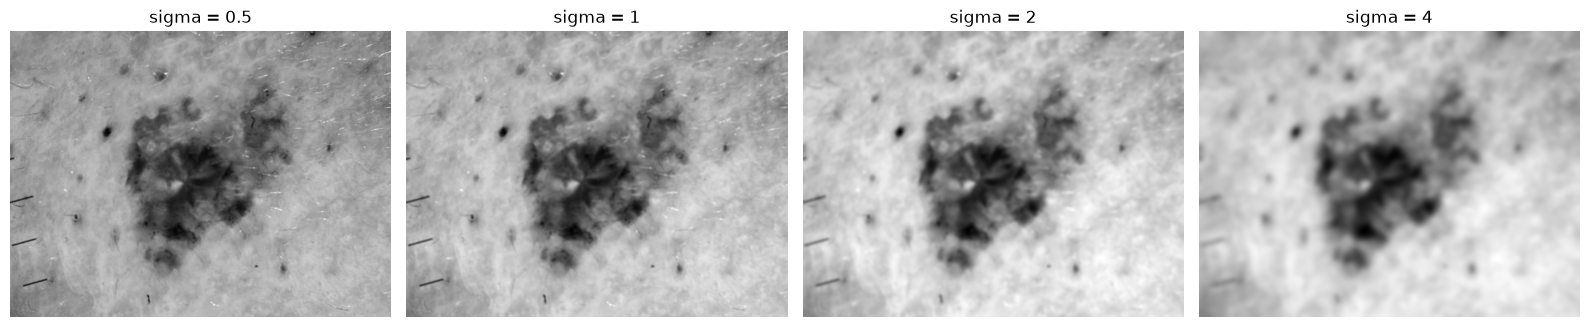

In [13]:
sigmas = [0.5, 1, 2, 4]

fig, axes = plt.subplots(
    1,
    len(sigmas),
    figsize=(16, 4)
)

for ax, sigma in zip(axes, sigmas):

    blurred = ndimage.gaussian_filter(
        img,
        sigma=sigma
    )

    ax.imshow(blurred, cmap="gray")
    ax.set_title(f"sigma = {sigma}")
    ax.axis("off")

plt.tight_layout()
plt.show()

In [14]:
for sigma in sigmas:

    blurred = ndimage.gaussian_filter(
        img,
        sigma=sigma
    )

    difference = np.mean(
        np.abs(img - blurred)
    )

    print(
        f"sigma={sigma}: "
        f"mean absolute difference={difference:.2f}"
    )

sigma=0.5: mean absolute difference=0.46
sigma=1: mean absolute difference=1.39
sigma=2: mean absolute difference=2.45
sigma=4: mean absolute difference=3.60


In [15]:
def canny_gradient(img, sigma=1.0):

    smoothed = ndimage.gaussian_filter(
        img.astype(float),
        sigma=sigma
    )

    gx = ndimage.sobel(
        smoothed,
        axis=1
    )

    gy = ndimage.sobel(
        smoothed,
        axis=0
    )

    magnitude = np.hypot(gx, gy)

    angle = np.rad2deg(
        np.arctan2(gy, gx)
    ) % 180

    return magnitude, angle

In [16]:
def non_maximum_suppression(magnitude, angle):

    height, width = magnitude.shape

    output = np.zeros_like(magnitude)

    for r in range(1, height - 1):
        for c in range(1, width - 1):

            direction = angle[r, c]

            if direction < 22.5 or direction >= 157.5:

                before = magnitude[r, c - 1]
                after = magnitude[r, c + 1]

            elif direction < 67.5:

                before = magnitude[r - 1, c + 1]
                after = magnitude[r + 1, c - 1]

            elif direction < 112.5:

                before = magnitude[r - 1, c]
                after = magnitude[r + 1, c]

            else:

                before = magnitude[r - 1, c - 1]
                after = magnitude[r + 1, c + 1]

            if (
                magnitude[r, c] >= before
                and magnitude[r, c] >= after
            ):
                output[r, c] = magnitude[r, c]

    return output

In [17]:
def hysteresis(
    image,
    low_threshold,
    high_threshold
):

    strong = image >= high_threshold

    weak = (
        (image >= low_threshold)
        & (image < high_threshold)
    )

    output = np.zeros(
        image.shape,
        dtype=np.uint8
    )

    output[strong] = 255

    height, width = image.shape

    changed = True

    while changed:

        changed = False

        for r in range(1, height - 1):
            for c in range(1, width - 1):

                if weak[r, c] and output[r, c] == 0:

                    neighborhood = output[
                        r - 1:r + 2,
                        c - 1:c + 2
                    ]

                    if np.any(
                        neighborhood == 255
                    ):
                        output[r, c] = 255
                        changed = True

    return output

In [18]:
def my_canny(
    img,
    sigma=1.0,
    low_threshold=20,
    high_threshold=50
):

    magnitude, angle = canny_gradient(
        img,
        sigma=sigma
    )

    suppressed = non_maximum_suppression(
        magnitude,
        angle
    )

    edges = hysteresis(
        suppressed,
        low_threshold,
        high_threshold
    )

    return edges

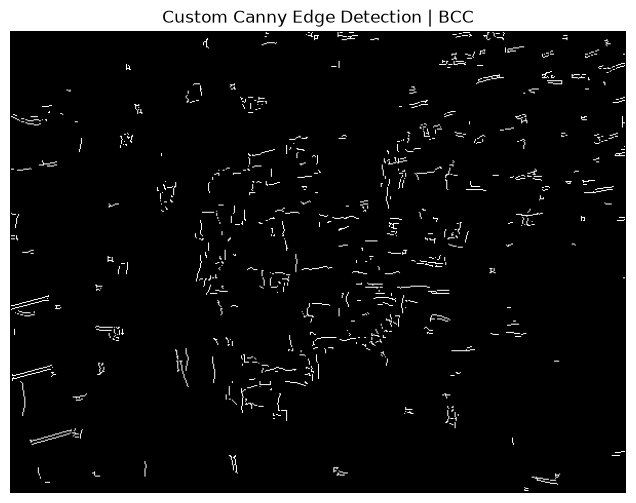

In [19]:
canny_result = my_canny(
    img,
    sigma=1.0,
    low_threshold=20,
    high_threshold=50
)

plt.figure(figsize=(8, 6))

plt.imshow(
    canny_result,
    cmap="gray"
)

plt.title(
    f"Custom Canny Edge Detection | {row['label']}"
)

plt.axis("off")
plt.show()

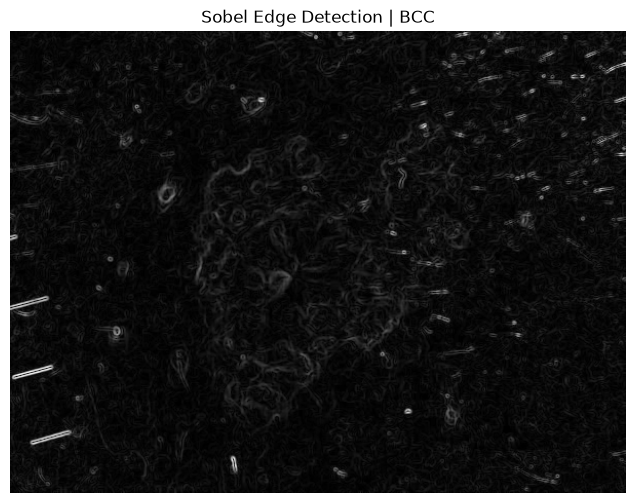

In [20]:
gx = ndimage.sobel(
    img,
    axis=1
)

gy = ndimage.sobel(
    img,
    axis=0
)

sobel_magnitude = np.hypot(
    gx,
    gy
)

plt.figure(figsize=(8, 6))

plt.imshow(
    sobel_magnitude,
    cmap="gray"
)

plt.title(
    f"Sobel Edge Detection | {row['label']}"
)

plt.axis("off")
plt.show()

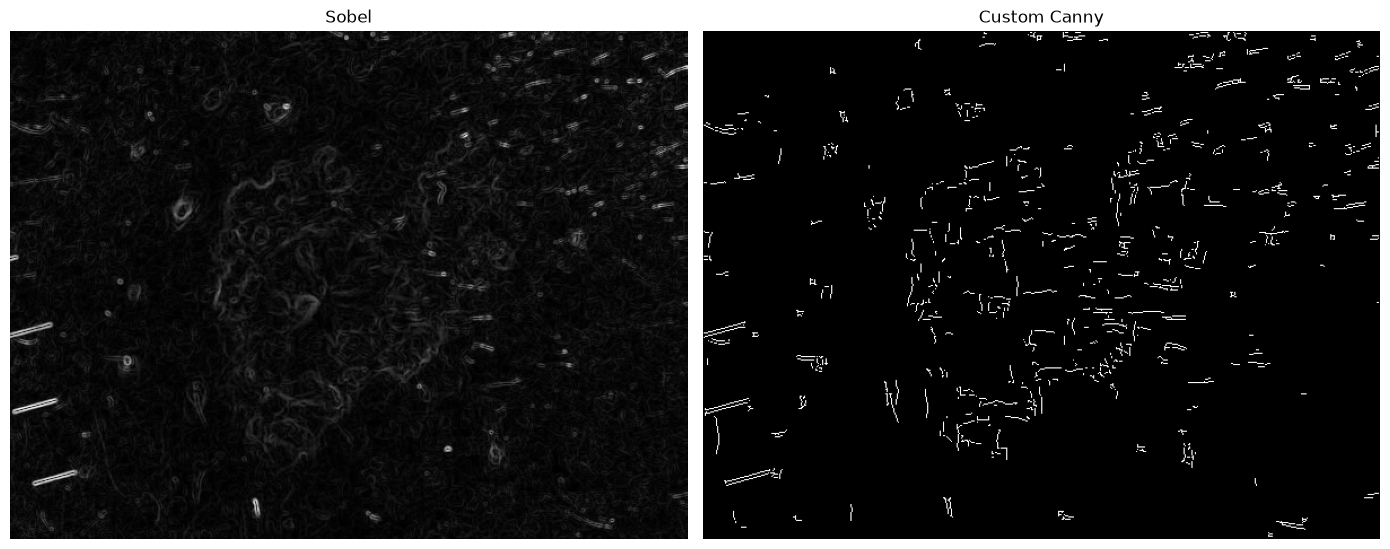

In [21]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 6)
)

axes[0].imshow(
    sobel_magnitude,
    cmap="gray"
)

axes[0].set_title("Sobel")

axes[1].imshow(
    canny_result,
    cmap="gray"
)

axes[1].set_title("Custom Canny")

for ax in axes:
    ax.axis("off")

plt.tight_layout()
plt.show()